In [13]:
%pip install koreanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
import koreanize_matplotlib

# 🎵 에스파(aespa) 뉴스 기사 텍스트 마이닝 분석! 🎵

안녕하세요 여러분! 👋
오늘은 뉴스 기사 데이터에서 원하는 정보를 쏙쏙 뽑아내는 **텍스트 마이닝(Text Mining)**에 대해 배워보고 실습해볼 거예요. 

오늘의 목표는 바로 **"뉴스 기사 본문에서 가장 많이 언급된 에스파 멤버는 누구일까?"** 입니다!

## 💡 텍스트 마이닝이란?
텍스트 마이닝(Text Mining)은 우리가 흔히 보는 뉴스, 책, 인터넷 게시글 같은 수많은 '글자(텍스트)'들 속에서 규칙을 찾고, 의미 있는 정보를 찾아내는 기술이에요. 
마치 광부가 광산에서 빛나는 보석을 캐내는 것처럼, 텍스트(Text) 속에서 보석 같은 정보(Keyword)를 캐내는(Mining) 작업이랍니다! 💎⛏️


## 🛠️ 준비하기: 필요한 패키지 설치 및 불러오기

In [15]:
!pip install pandas matplotlib wordcloud openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [16]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [17]:
import matplotlib.font_manager as fm

# 시스템에 설치된 모든 TTF 폰트 파일의 경로를 가져옵니다.
font_paths = fm.findSystemFonts(fontpaths=None, fontext='ttf')

# (선택 사항) 너무 많을 수 있으니, "Nanum"(나눔), "Gothic"(고딕), "Malgun"(맑은) 등 
# 한글 폰트 이름이 포함된 경로만 필터링해서 출력해 볼 수 있습니다.
for path in font_paths:
    if 'Nanum' in path or 'Gothic' in path or 'Malgun' in path: # 원하는 이름으로 변경 가능
        print(path)
path

/usr/share/fonts/opentype/urw-base35/URWGothic-Demi.otf
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf
/usr/share/fonts/opentype/urw-base35/URWGothic-DemiOblique.otf
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf
/usr/share/fonts/opentype/urw-base35/URWGothic-BookOblique.otf
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf
/usr/share/fonts/truetype/nanum/NanumGothic.ttf
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf
/usr/share/fonts/opentype/urw-base35/URWGothic-Book.otf
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjo.ttf
/usr/share/fonts/truetype/nanum/NanumMyeongjoBold.ttf
/usr/share/fonts/truetype/noto/NotoSansGothic-Regular.ttf
/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf


'/usr/share/fonts/truetype/liberation/LiberationSans-Italic.ttf'

## 1단계: 뉴스 기사 데이터 가져오기 📄

In [18]:
df = pd.read_excel('data.xlsx')
display(df.head())

/home/an0jin/.local/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,뉴스 식별자,일자,언론사,기고자,제목,통합 분류1,통합 분류2,통합 분류3,사건/사고 분류1,사건/사고 분류2,사건/사고 분류3,인물,위치,기관,키워드,특성추출(가중치순 상위 50개),본문,URL,분석제외 여부
0,1.101101e+06,20260413,한국일보,고경석,"빅뱅 ""우리가 돌아왔다"" 美 최대 음악축제서 20주년 자축 파티",문화>전시_공연,문화>방송_연예,문화>음악,NaN,NaN,NaN,"K팝,샤이니,에스파,빅뱅,대성,혁오,헌트릭스,에이티즈,잠비나이,에픽하이","미국,태민도,일본,코첼라,대성,휴양,캘리포니아주,한국,인디오,헌터스,美,태양","대성,코첼라,케이팝 데몬,태양,한미 합작 걸그룹","빅뱅,음악축제,최대,음악,축제,파티,주년,자축,GD,무대,코첼라,헤드라이너,공연캣츠...","코첼라,대성,미국,걸그룹,트로트,빅뱅이,히트곡,지드래곤,주년,팬들,헤드라이너,그간,...","“안녕, 코첼라, 오랜만이야. 빅뱅이 돌아왔어.”\n그룹 빅뱅의 지드래곤이 특유의 ...",https://www.hankookilbo.com/news/article/A2026...,NaN
1,1.010010e+07,20260413,스포츠서울,위수정 기자,"에스파 카리나, 밤 벚꽃 아래 여신 비주얼 “아름다웠어”",문화>방송_연예,문화>영화,문화>전시_공연,NaN,NaN,NaN,NaN,NaN,aeXIS,"에스파,카리,벚꽃,여신,비주얼,사진ㅣ카리,SNS,그룹,에스파,aespa,멤버,카리나...","카리나,카리,팬들,에스파,사진ㅣ카리,보라색,aespa,봄기운,머릿결,크로셰,몽환적,...",사진ㅣ카리나 SNS\n \n\n[스포츠서울 | 위수정 기자] 그룹 에스파(aespa...,https://www.sportsseoul.com/news/read/1602278,NaN
2,2.100101e+06,20260413,매일경제,양소영 스타투데이 기자(skyb1842@mkinternet.com),"에스파 카리나, 벚꽃 미소...“완벽하게 근사한 순간들”",문화>방송_연예,문화>종교,문화>출판,NaN,NaN,NaN,NaN,NaN,26,"에스파,카리,벚꽃,미소,완벽,순간들,카리나,그룹,에스파,벚꽃,미소,포착,에스파,카리...","카리나,에스파,팬들,인스타그램,페미닌,액시스,카디건,팬심,순간들,카리,시간date,...",그룹 에스파 카리나의 벚꽃 미소가 포착됐다.\n에스파 카리나는 13일 인스타그램에 ...,http://www.mk.co.kr/article/12015664,NaN
3,1.010040e+07,20260413,스포츠월드,노희선 기자,카리나가 말하는 ‘완벽하게 근사한 순간’ 밤 벚꽃보다 빛나는 찰나 [스타★샷],문화>방송_연예,문화>생활,문화>영화,NaN,NaN,NaN,카리나,NaN,NaN,"카리나,완벽,순간,벚꽃,찰나,스타,카리나,벚꽃,미모,출처,카리나,인스타그램,에스파,...","카리나,이목구비,인스타그램,보랏빛,보헤미안,팬들,감각적,사회관계망서비스,누리꾼,하나...",카리나가 밤 벚꽃 아래에서 미모를 뽐냈다. 출처=카리나 인스타그램 에스파(aespa...,http://www.sportsworldi.com/content/html/2026/...,NaN
4,1.010030e+07,20260411,스포츠한국,이유민 기자,"""유병재 비주얼 충격이네"" 유병재, 카리나 '슈퍼노바' 코스프레 등장 현장 초토화",문화>방송_연예,문화>출판,문화>영화,NaN,NaN,NaN,"김기현,킹키,짱구,김두영,에스파,김경욱,성우,카리나",파주,"유튜브,게스","충격,유병재,비주얼,유병재,카리,슈퍼노바,코스프레,등장,현장,초토화,그룹,에스파,a...","카리나,유병재,성우,에스파,출연진,개그맨,슈퍼노바,김경욱,참가자,카리,뮤직비디오,유...",[스포츠한국 이유민 기자] \n\n그룹 에스파(aespa)의 카리나가 자신의 생일을...,https://sports.hankooki.com/news/articleView.h...,NaN


## 2단계: 데이터 전처리 (고유 식별자 중복 제거 & 에스파 찾기) 🧹
- 똑같은 내용의 뉴스는 빼고 하나만 남깁니다 (**'뉴스 식별자'** 기준으로 아주 기계적이고 완벽한 중복 제거!).
- 기사 내용 중에서 불필요한 것들은 빼고 가장 중요한 **'제목'과 '본문'** 컬럼만 골라냅니다.
- 에스파 또는 멤버 이름이 없는 관련 없는 기사는 지웁니다!

In [19]:
# 1. 중복된 뉴스 완벽하게 지우기 (뉴스 식별자 기준)
try:
    df = df.drop_duplicates(subset=['뉴스 식별자'])
except:
    print("'뉴스 식별자' 열을 찾을 수 없어 일반적인 중복 제거를 진행합니다.")
    df = df.drop_duplicates()

# 2. 분석에 필요한 특정 컬럼('제목', '본문')만 남기고 다 버리기
try:
    df = df[['제목', '본문']]
except KeyError:
    print("💡 엑셀에 '제목', '본문' 이라는 열이 없어서 전체 텍스트를 모두 활용합니다.")

# 3. 기사 안에서 찾아볼 키워드
aespa_keywords = ['에스파', 'aespa', '카리나', '윈터', '지젤', '닝닝']

def check_contain_aespa(row):
    try:
        row_text = str(row['제목']) + " " + str(row['본문'])
    except:
        row_text = ' '.join(row.dropna().astype(str).tolist())
        
    for keyword in aespa_keywords:
        if keyword in row_text:
            return True
    return False

df_filtered = df[df.apply(check_contain_aespa, axis=1)]

print(f"가공 전 원래 데이터 개수: {len(df)}개")
print(f"가공 후 에스파 관련 데이터 개수: {len(df_filtered)}개")

가공 전 원래 데이터 개수: 355개
가공 후 에스파 관련 데이터 개수: 184개


## 3단계: 오직 '본문'에서만 멤버별 언급 횟수 세기 ✨
제목보다는 내용이 꽉 찬 **기사 본문(body)**에서 각 멤버 이름이 몇 번씩 나왔는지 세어보겠습니다!

In [20]:
members = ['카리나', '윈터', '지젤', '닝닝']

try:
    all_text = ' '.join(df_filtered['본문'].dropna().astype(str).values)
except:
    all_text = ' '.join(df_filtered.astype(str).values.flatten())

mention_counts = {}
for member in members:
    count = all_text.count(member)
    mention_counts[member] = count
    print(f"💖 {member}: {count}번 본문에서 언급됨")

💖 카리나: 198번 본문에서 언급됨
💖 윈터: 125번 본문에서 언급됨
💖 지젤: 51번 본문에서 언급됨
💖 닝닝: 37번 본문에서 언급됨


## 4단계: 시각화(1) - 막대그래프로 언급 횟수 비교하기 📊
가장 기본적인 차트입니다! 어디 한 번 누가 가장 많이 나왔는지 막대그래프로 길이를 비교해볼까요?

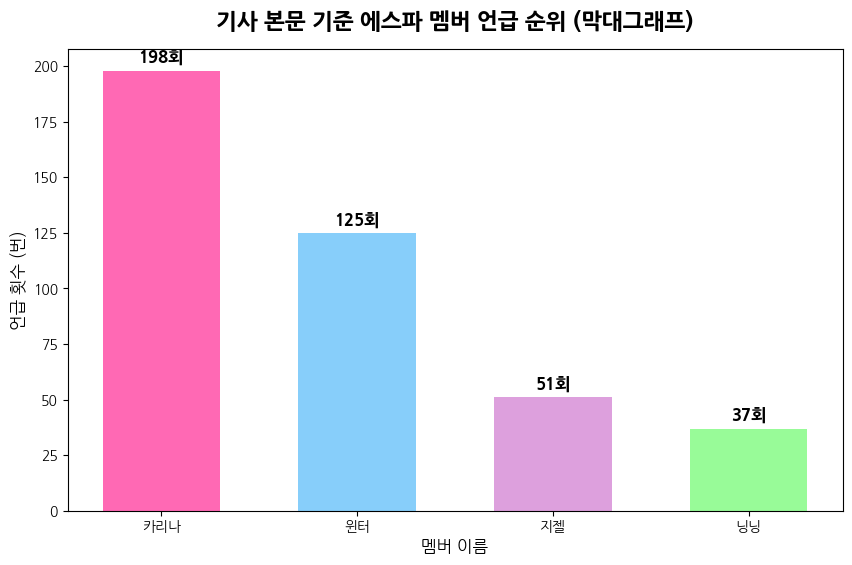

In [21]:
plt.figure(figsize=(10, 6))
colors = ['#FF69B4', '#87CEFA', '#DDA0DD', '#98FB98'] 
plt.bar(mention_counts.keys(), mention_counts.values(), color=colors, width=0.6)
plt.title('기사 본문 기준 에스파 멤버 언급 순위 (막대그래프)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('멤버 이름', fontsize=12)
plt.ylabel('언급 횟수 (번)', fontsize=12)
for i, count in enumerate(mention_counts.values()):
    plt.text(i, count + (max(mention_counts.values() if mention_counts.values() else [1])*0.02), f"{count}회", ha='center', fontsize=12, fontweight='bold')
plt.show()

## 5단계: 시각화(2) - 전체 중에 얼마나 차지할까? (원그래프) 🥧
막대그래프는 누가 누구보다 많은지 길이를 볼 수 있다면, 원그래프(파이 차트)는 전체 파이 한 판 중에 각 멤버가 차지하는 **'비율(%)'** 혹은 지분율을 보기에 아주 좋습니다!
누가 제일 큰 조각을 가졌을까요?

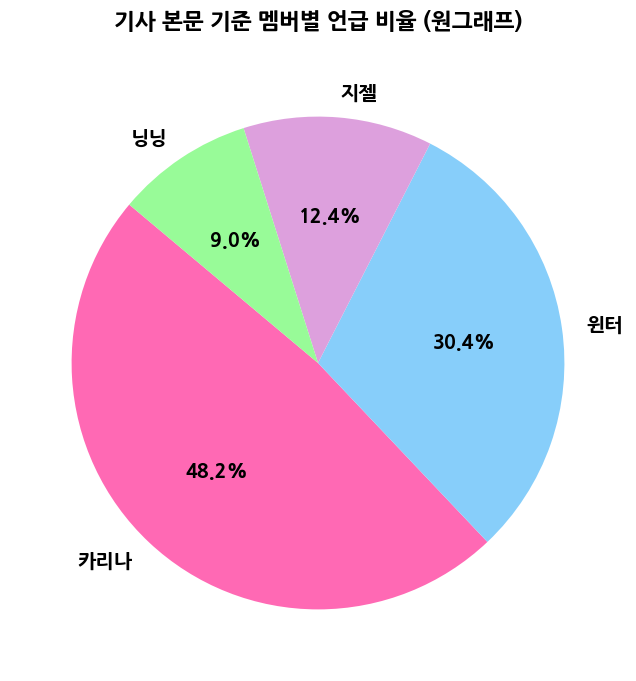

In [22]:
plt.figure(figsize=(8, 8))

# 언급된 멤버가 아무도 없는 경우 에러 방지
if sum(mention_counts.values()) > 0:
    # 원그래프 그리기
    # autopct='%1.1f%%': 퍼센트(%)를 소수점 첫째 자리까지 표시하라는 의미입니다.
    plt.pie(mention_counts.values(), labels=mention_counts.keys(), autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 14, 'fontweight': 'bold'})
    plt.title('기사 본문 기준 멤버별 언급 비율 (원그래프)', fontsize=16, fontweight='bold', pad=20)
else:
    plt.text(0.5, 0.5, '언급된 멤버가 없어 파이 차트를 그릴 수 없습니다!', ha='center', va='center', fontsize=14)
    plt.axis('off')

plt.show()

## 6단계: 시각화(3) - 가장 직관적인 워드클라우드 ☁️
많이 나온 이름은 크게 보여주는 워드클라우드를 그려봅시다.

In [23]:
!apt-get install -y fonts-nanum

E: 잠금 파일 /var/lib/dpkg/lock-frontend 파일을 열 수 없습니다 - open (13: 허가 거부)
E: Unable to acquire the dpkg frontend lock (/var/lib/dpkg/lock-frontend), are you root?


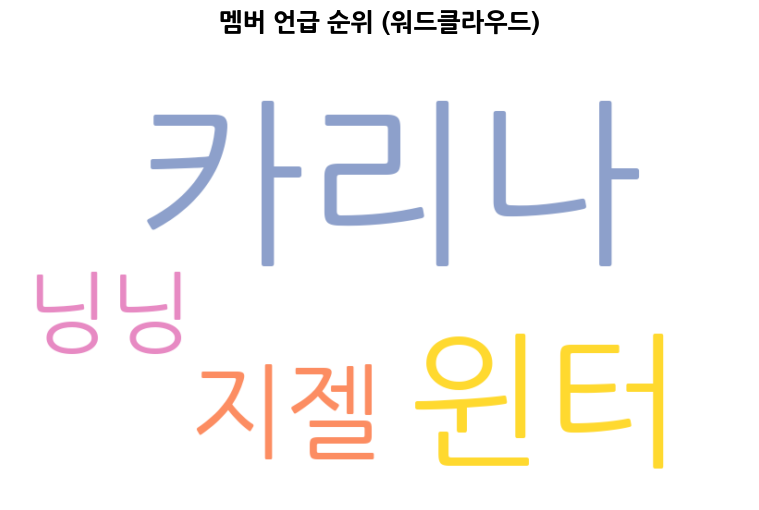

In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import os

# 1. 폰트 경로 설정 (실제 파일 존재 여부 확인 필수)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 2. 데이터 존재 확인 및 생성
if mention_counts:
    # 빈도수 딕셔너리를 직접 전달 (generate -> generate_from_frequencies)
    wc = WordCloud(            
        background_color='white',        
        width=800,                       
        height=500,                      
        colormap='Set2',
        font_path=font_path                  
    ).generate_from_frequencies(mention_counts)
    
    # 3. 시각화
    plt.figure(figsize=(10, 6))
    plt.imshow(wc, interpolation='bilinear') 
    plt.axis('off') 
    plt.title('멤버 언급 순위 (워드클라우드)', fontsize=18, fontweight='bold')
    plt.show()
else:
    print("데이터가 없어 워드클라우드를 생성할 수 없습니다.")

## 🎉 마무리!
여러분, 수고 많았습니다! 🥳 
오늘 우리는 **가장 확실한 기준(고유 식별자)**으로 쓰레기 데이터를 걸러내고(전처리), 세 가지 종류의 시각화(**막대그래프, 원그래프, 워드클라우드**)를 기분에 맞춰 자유자재로 다루며 다각도로 **텍스트 마이닝 분석**을 마쳤습니다!
이처럼 데이터 특성에 맞춰 다양한 형태의 시각화를 고를 줄 안다면, 여러분은 이미 준비된 훌륭한 데이터 전문가입니다 👍